# Manual SNR Diagnostics

This notebook studies the SNR values saved in `manual_spike_detection_results.pkl` and recomputes a framewise `SNR_interpolated` diagnostic from the manual spike-detection SNR formula.

The three outputs are:

1. Distribution of saved overall SNR across all manually processed cells.
2. Segment-wise SNR change up to the manual SNR cutoff, `(last segment - first segment) / first segment`.
3. Distribution of frame-removal percentages after applying `SNR_interpolated < 3.5` to frames that were still valid under the manual masks.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import pickle
from pathlib import Path
from typing import Any

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

current_dir = Path(os.getcwd()).resolve()
if current_dir.name == "notebooks_PCs_refined":
    project_root = current_dir.parent
else:
    project_root = current_dir
if not (project_root / "data").exists():
    project_root = Path("/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4").resolve()
repo_root = project_root.parent
# The repository root also has a utils package. Keep the analysis project first
# and remove the repo root so imports resolve to miniVI_PlaceCell_analysis_V4/utils.
os.chdir(project_root)
repo_root_str = str(repo_root)
sys.path = [p for p in sys.path if Path(p or os.getcwd()).resolve() != repo_root]
project_root_str = str(project_root)
if project_root_str in sys.path:
    sys.path.remove(project_root_str)
sys.path.insert(0, project_root_str)

from utils import placecell_pipeline as pcp
from dash_manual_spike_detection_app.pipeline import calculate_segment_snr

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "ytick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})

print(f"Project root: {project_root}")

Project root: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4


In [2]:
ANIMAL_IDS = [
    "CKII_pAce21_PR_20250806",
    "CKII_pAce38_PX_20251126",
    "CKII_pAce45_PX_20260118",
    "CKII_pAce47_PX_20260128",
    "CKII_pAce46_PR_20260222",
    "CKII_pAce50_PRL_20260317",
    "CKII_pAce54_PR_20260506",
    "CKII_pAce54_PX_20260514",
]

MANUAL_SIDECAR_FILENAME = "manual_spike_detection_results.pkl"
MERGED_DATA_FILENAME = "merged_aligned_data.pkl"
SNR_THRESHOLD = 5
APPLY_CB_BASELINE_REMOVAL = False
CB_BASELINE_WINDOW_S = None

DATA_ROOT = project_root / "data"
FIGURES_ROOT = project_root / "figures"
figure_save_folder = FIGURES_ROOT / "CKII_pooled" / "SNR_manual_sidecar_diagnostics"
figure_save_folder.mkdir(parents=True, exist_ok=True)

print(f"Figures will be saved to: {figure_save_folder}")

Figures will be saved to: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SNR_manual_sidecar_diagnostics


## Load Manual Sidecars

The sidecar has the values that were saved by the manual spike-detection app: `overall_snr`, `segment_snr`, `segment_snr_noise`, `segment_snr_baseline_counts`, manual exclusion periods, and `snr_acceptable_until_s`.

In [3]:
def load_pickle(path: Path) -> Any:
    with Path(path).open("rb") as f:
        return pickle.load(f)


def as_1d_float(value: Any, n: int | None = None, fill: float = np.nan) -> np.ndarray:
    arr = np.asarray(value if value is not None else [], dtype=float).reshape(-1)
    if n is None:
        return arr
    if arr.size < n:
        arr = np.concatenate([arr, np.full(n - arr.size, fill, dtype=float)])
    elif arr.size > n:
        arr = arr[:n]
    return arr


def load_animal_payload(animal_id: str) -> dict[str, Any]:
    animal_dir = DATA_ROOT / animal_id
    sidecar = pcp._load_manual_sidecar(animal_dir, sidecar_filename=MANUAL_SIDECAR_FILENAME)
    cells = pcp._manual_sidecar_cells(sidecar)
    if not cells:
        raise ValueError(f"No manual cells found in {animal_dir / MANUAL_SIDECAR_FILENAME}")

    merged_path = animal_dir / MERGED_DATA_FILENAME
    if not merged_path.exists():
        fallback = animal_dir / "merged_aligned_data_CS.pkl"
        merged_path = fallback if fallback.exists() else merged_path
    if not merged_path.exists():
        raise FileNotFoundError(f"Missing merged source for {animal_id}: {merged_path}")
    merged = load_pickle(merged_path)

    x = as_1d_float(merged.get("x_neural", []))
    y = as_1d_float(merged.get("y_neural", np.full_like(x, np.nan)), n=x.size)
    speed = as_1d_float(merged.get("speed", np.full_like(x, np.nan)), n=x.size)
    n_frames = int(min(x.size, y.size, speed.size))
    if n_frames <= 0:
        refined = sidecar.get("refined_analysis_data", {}) if isinstance(sidecar.get("refined_analysis_data"), dict) else {}
        n_frames = int(refined.get("n_frames", 0))
    if n_frames <= 0:
        raise ValueError(f"Cannot determine n_frames for {animal_id}")

    x = as_1d_float(x, n=n_frames)
    y = as_1d_float(y, n=n_frames)
    speed = as_1d_float(speed, n=n_frames)
    pos_nan_mask = (~np.isfinite(x)) | (~np.isfinite(y)) | (~np.isfinite(speed))

    frame_rate = float(sidecar.get("frame_rate", merged.get("frame_rate", np.nan)))
    if not np.isfinite(frame_rate) or frame_rate <= 0:
        raise ValueError(f"Invalid frame_rate for {animal_id}: {frame_rate!r}")

    return {
        "animal_id": animal_id,
        "animal_dir": animal_dir,
        "sidecar": sidecar,
        "cells": cells,
        "merged": merged,
        "merged_path": merged_path,
        "raw_trace_source": merged.get("traces", []),
        "frame_rate": frame_rate,
        "n_frames": n_frames,
        "x": x,
        "y": y,
        "speed": speed,
        "pos_nan_mask": pos_nan_mask,
    }


def padded_segment_values(values: Any, bounds: list[tuple[int, int]]) -> np.ndarray:
    out = np.full(len(bounds), np.nan, dtype=float)
    raw = np.asarray(values if values is not None else [], dtype=float).reshape(-1)
    n = min(out.size, raw.size)
    if n > 0:
        out[:n] = raw[:n]
    return out


def segment_centers_s(bounds: list[tuple[int, int]], frame_rate: float) -> np.ndarray:
    centers = np.asarray([(float(start) + float(end) - 1.0) / 2.0 for start, end in bounds], dtype=float)
    return centers / float(frame_rate)


def manual_snr_cutoff_s(cell: dict[str, Any], n_frames: int, frame_rate: float) -> float:
    max_time_s = float(n_frames) / float(frame_rate)
    try:
        value = float(cell.get("snr_acceptable_until_s", max_time_s))
    except Exception:
        value = max_time_s
    if not np.isfinite(value):
        value = max_time_s
    return float(np.clip(value, 0.0, max_time_s))


def manual_snr_cutoff_mask(cell: dict[str, Any], n_frames: int, frame_rate: float) -> np.ndarray:
    cutoff_s = manual_snr_cutoff_s(cell, n_frames, frame_rate)
    cutoff_frame = int(np.floor(cutoff_s * float(frame_rate)))
    cutoff_frame = int(np.clip(cutoff_frame, 0, n_frames))
    mask = np.zeros(int(n_frames), dtype=bool)
    if cutoff_frame < n_frames:
        mask[cutoff_frame:] = True
    return mask


def save_svg(fig: plt.Figure, filename: str) -> Path:
    out_path = figure_save_folder / filename
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {out_path}")
    return out_path


def polish_axis(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(width=0.5)

In [4]:
animal_payloads = {animal_id: load_animal_payload(animal_id) for animal_id in ANIMAL_IDS}

cell_rows = []
for animal_id, payload in animal_payloads.items():
    frame_rate = payload["frame_rate"]
    n_frames = payload["n_frames"]
    for cell_idx, cell in sorted(payload["cells"].items()):
        bounds = pcp._manual_segment_bounds(cell, n_frames)
        segment_snr = padded_segment_values(cell.get("segment_snr", []), bounds)
        segment_counts = padded_segment_values(cell.get("segment_snr_baseline_counts", []), bounds)
        cell_rows.append({
            "animal_id": animal_id,
            "cell_idx": int(cell_idx),
            "frame_rate": frame_rate,
            "n_frames": int(n_frames),
            "duration_min": float(n_frames) / float(frame_rate) / 60.0,
            "n_segments": len(bounds),
            "n_segment_snr_finite": int(np.sum(np.isfinite(segment_snr))),
            "overall_snr_saved": float(cell.get("overall_snr", np.nan)),
            "snr_acceptable_until_s": manual_snr_cutoff_s(cell, n_frames, frame_rate),
            "manual_exclusion_frames": int(np.sum(pcp._manual_period_mask(n_frames, cell.get("manual_exclusion_periods", [])))),
            "segment_baseline_count_min": float(np.nanmin(segment_counts)) if np.any(np.isfinite(segment_counts)) else np.nan,
        })

cell_df = pd.DataFrame(cell_rows).sort_values(["animal_id", "cell_idx"]).reset_index(drop=True)
print(f"Loaded {len(animal_payloads)} animals and {len(cell_df)} manually processed cells.")
display(cell_df.head())
display(cell_df.groupby("animal_id").agg(n_cells=("cell_idx", "count"), median_overall_snr=("overall_snr_saved", "median")))

Loaded 8 animals and 89 manually processed cells.


,animal_id,cell_idx,frame_rate,n_frames,duration_min,n_segments,n_segment_snr_finite,overall_snr_saved,snr_acceptable_until_s,manual_exclusion_frames,segment_baseline_count_min
0,CKII_pAce21_PR_20250806,0,500.0,299500,9.983333,5,5,7.498422,599.0,5623,52247.0
1,CKII_pAce21_PR_20250806,1,500.0,299500,9.983333,5,5,6.706071,599.0,545,50678.0
2,CKII_pAce21_PR_20250806,2,500.0,299500,9.983333,5,5,7.653611,599.0,3589,50676.0
3,CKII_pAce21_PR_20250806,3,500.0,299500,9.983333,5,5,5.451571,599.0,3783,53654.0
4,CKII_pAce21_PR_20250806,4,500.0,299500,9.983333,5,5,4.604557,599.0,4462,53766.0


,n_cells,median_overall_snr
animal_id,,
CKII_pAce21_PR_20250806,9,6.356864
CKII_pAce38_PX_20251126,9,5.723867
CKII_pAce45_PX_20260118,16,4.883120
CKII_pAce46_PR_20260222,9,5.352692
CKII_pAce47_PX_20260128,5,7.737523
CKII_pAce50_PRL_20260317,9,5.928770
CKII_pAce54_PR_20260506,16,6.153988
CKII_pAce54_PX_20260514,16,4.902896


## Saved Overall SNR Distribution

`overall_snr` is the mean of finite segment SNR values saved by the manual app. The segment SNR formula masks nonfinite residuals, complex bursts, failed complex-burst windows, manual exclusions, and a small window around saved spikes before calculating the residual-noise standard deviation.

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SNR_manual_sidecar_diagnostics/ManualSidecar_OverallSNR_Distribution.svg


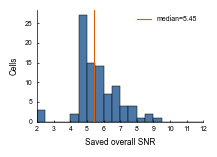

,overall_snr_saved
count,89.000000
mean,5.662487
std,1.278463
min,2.096878
10%,4.576914
25%,4.889062
50%,5.451571
75%,6.412582
90%,7.424103
max,9.442586


In [5]:
overall = cell_df["overall_snr_saved"].to_numpy(dtype=float)
overall = overall[np.isfinite(overall)]

fig, ax = plt.subplots(figsize=(2.15, 1.55))
snr_bin_size = 0.5
snr_bin_max = max(12.0, np.ceil(np.nanmax(overall) / snr_bin_size) * snr_bin_size)
bins = np.arange(0, snr_bin_max + snr_bin_size, snr_bin_size)
ax.hist(overall, bins=bins, color="#4C78A8", edgecolor="black", linewidth=0.35)
ax.axvline(np.nanmedian(overall), color="#D95F02", linewidth=0.8, label=f"median={np.nanmedian(overall):.2f}")
ax.set_xlim(2,10)
ax.set_xticks(np.arange(2, snr_bin_max + 1, 1))
ax.set_xlabel("Saved overall SNR")
ax.set_ylabel("Cells")
ax.legend(frameon=False)
polish_axis(ax)
fig.tight_layout()
save_svg(fig, "ManualSidecar_OverallSNR_Distribution.svg")
plt.show()

summary_overall = pd.Series(overall).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame("overall_snr_saved")
display(summary_overall)

## Segment-Wise SNR Change Up To Manual Cutoff

For each cell, this uses the saved `segment_snr` values and keeps finite segments whose segment center is before `snr_acceptable_until_s`. The reported percentage is `100 * (last - first) / first`.

In [6]:
def snr_change_until_manual_cutoff(cell: dict[str, Any], n_frames: int, frame_rate: float) -> dict[str, Any]:
    bounds = pcp._manual_segment_bounds(cell, n_frames)
    snr = padded_segment_values(cell.get("segment_snr", []), bounds)
    centers_s = segment_centers_s(bounds, frame_rate)
    cutoff_s = manual_snr_cutoff_s(cell, n_frames, frame_rate)
    keep = np.isfinite(snr) & (centers_s <= cutoff_s)
    idx = np.flatnonzero(keep)
    out = {
        "snr_change_pct_until_manual_cutoff": np.nan,
        "first_segment_snr": np.nan,
        "last_segment_snr": np.nan,
        "first_segment_center_s": np.nan,
        "last_segment_center_s": np.nan,
        "n_segments_used_for_change": int(idx.size),
    }
    if idx.size == 0:
        return out
    first_i = int(idx[0])
    last_i = int(idx[-1])
    first = float(snr[first_i])
    last = float(snr[last_i])
    out.update({
        "first_segment_snr": first,
        "last_segment_snr": last,
        "first_segment_center_s": float(centers_s[first_i]),
        "last_segment_center_s": float(centers_s[last_i]),
    })
    if np.isfinite(first) and first > 0:
        out["snr_change_pct_until_manual_cutoff"] = float(100.0 * (last - first) / first)
    return out

change_rows = []
for animal_id, payload in animal_payloads.items():
    for cell_idx, cell in sorted(payload["cells"].items()):
        row = {
            "animal_id": animal_id,
            "cell_idx": int(cell_idx),
            "snr_acceptable_until_s": manual_snr_cutoff_s(cell, payload["n_frames"], payload["frame_rate"]),
        }
        row.update(snr_change_until_manual_cutoff(cell, payload["n_frames"], payload["frame_rate"]))
        change_rows.append(row)

snr_change_df = pd.DataFrame(change_rows).sort_values(["animal_id", "cell_idx"]).reset_index(drop=True)
display(snr_change_df.head())
display(snr_change_df["snr_change_pct_until_manual_cutoff"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame())

,animal_id,cell_idx,snr_acceptable_until_s,snr_change_pct_until_manual_cutoff,first_segment_snr,last_segment_snr,first_segment_center_s,last_segment_center_s,n_segments_used_for_change
0,CKII_pAce21_PR_20250806,0,599.0,-25.341090,8.673195,6.475313,59.999,539.499,5
1,CKII_pAce21_PR_20250806,1,599.0,-6.889788,6.943199,6.464827,59.999,539.499,5
2,CKII_pAce21_PR_20250806,2,599.0,-6.587602,7.597260,7.096783,59.999,539.499,5
3,CKII_pAce21_PR_20250806,3,599.0,-7.704735,5.509295,5.084819,59.999,539.499,5
4,CKII_pAce21_PR_20250806,4,599.0,4.318625,4.320253,4.506828,59.999,539.499,5


,snr_change_pct_until_manual_cutoff
count,81.000000
mean,-18.098516
std,17.656114
min,-61.558069
10%,-41.614153
25%,-28.116367
50%,-14.370325
75%,-4.932366
90%,2.314536
max,9.349108


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SNR_manual_sidecar_diagnostics/ManualSidecar_SegmentSNRChange_UntilManualCutoff.svg


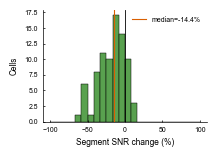

In [7]:
change = snr_change_df["snr_change_pct_until_manual_cutoff"].to_numpy(dtype=float)
change = change[np.isfinite(change)]

fig, ax = plt.subplots(figsize=(2.15, 1.55))
lo = min(-100.0, np.nanpercentile(change, 1) if change.size else -100.0)
hi = max(100.0, np.nanpercentile(change, 99) if change.size else 100.0)
bins = np.linspace(lo, hi, 25)
ax.hist(change, bins=bins, color="#59A14F", edgecolor="black", linewidth=0.35)
ax.axvline(0, color="black", linewidth=0.6)
ax.axvline(np.nanmedian(change), color="#D95F02", linewidth=0.8, label=f"median={np.nanmedian(change):.1f}%")
ax.set_xlabel("Segment SNR change (%)")
ax.set_ylabel("Cells")
ax.legend(frameon=False)
polish_axis(ax)
fig.tight_layout()
save_svg(fig, "ManualSidecar_SegmentSNRChange_UntilManualCutoff.svg")
plt.show()

## Recompute Step4-Style Framewise `SNR_interpolated`

The manual app computes segment SNR from `trace_spike_height_normalized - vm_spike_height_normalized`. In spike-height units, the signal numerator is 1, so segment SNR is `1 / std(residual baseline noise)` after masking spikes, complex-burst windows, failed complex-burst windows, manual exclusion periods, and nonfinite values.

This section reconstructs the normalized trace from the raw merged trace and saved manual parameters, recomputes the segment SNR with the same formula, then linearly interpolates finite segment SNR values at segment centers to every frame. The SNR threshold is applied only to frames that are still valid after the manual exclusion mask, position/trace nonfinite mask, and manual `snr_acceptable_until_s` cutoff.

In [8]:
def interpolate_segment_snr(segment_snr: np.ndarray, bounds: list[tuple[int, int]], n_frames: int) -> np.ndarray:
    values = np.asarray(segment_snr, dtype=float).reshape(-1)
    if values.size < len(bounds):
        padded = np.full(len(bounds), np.nan, dtype=float)
        padded[:values.size] = values
        values = padded
    elif values.size > len(bounds):
        values = values[:len(bounds)]
    centers = np.asarray([(float(start) + float(end) - 1.0) / 2.0 for start, end in bounds], dtype=float)
    finite = np.isfinite(values) & np.isfinite(centers)
    out = np.full(int(n_frames), np.nan, dtype=np.float32)
    if not np.any(finite):
        return out
    frame_idx = np.arange(int(n_frames), dtype=float)
    if np.sum(finite) == 1:
        out[:] = float(values[finite][0])
    else:
        out[:] = np.interp(frame_idx, centers[finite], values[finite], left=values[finite][0], right=values[finite][-1]).astype(np.float32)
    return out


def recompute_step4_snr_for_cell(payload: dict[str, Any], cell_idx: int) -> dict[str, Any]:
    animal_id = payload["animal_id"]
    cell = payload["cells"][int(cell_idx)]
    frame_rate = float(payload["frame_rate"])
    n_frames = int(payload["n_frames"])

    raw_trace = pcp._manual_trace_for_cell(payload["raw_trace_source"], int(cell_idx), n_frames)
    normalized = pcp._manual_cell_normalized_traces(
        raw_trace,
        cell,
        frame_rate,
        n_frames,
        apply_cb_baseline_removal=APPLY_CB_BASELINE_REMOVAL,
        cb_baseline_window_s=CB_BASELINE_WINDOW_S,
    )
    trace_norm = np.asarray(normalized["trace_spike_height_normalized"], dtype=float)
    vm_norm = np.asarray(normalized["vm_spike_height_normalized"], dtype=float)
    noise_trace = trace_norm - vm_norm
    bounds = normalized["segment_bounds"]
    spikes = pcp._manual_spike_array(cell.get("spikes", []), n_frames)
    complex_bursts = pcp._manual_complex_burst_dict(cell, trace_norm, vm_norm)
    failed_windows = cell.get("failed_min_spikes_after_amp_duration_windows", None)
    spike_mask_ms = float(cell.get("snr_spike_mask_ms", 3.0))

    snr_result = calculate_segment_snr(
        noise_trace,
        bounds,
        spikes,
        frame_rate,
        complex_bursts=complex_bursts,
        failed_min_spikes_windows=failed_windows,
        manual_exclusion_periods=cell.get("manual_exclusion_periods", []),
        spike_mask_ms=spike_mask_ms,
    )
    snr_interp = interpolate_segment_snr(snr_result["segment_snr"], bounds, n_frames)

    trace_bad = ~np.isfinite(trace_norm)
    manual_exclusion_mask = np.asarray(normalized["manual_exclusion_mask"], dtype=bool)
    manual_bad_mask = (
        np.asarray(payload["pos_nan_mask"], dtype=bool) |
        trace_bad |
        manual_exclusion_mask |
        manual_snr_cutoff_mask(cell, n_frames, frame_rate)
    )
    manual_good = ~manual_bad_mask
    threshold_bad = manual_good & np.isfinite(snr_interp) & (snr_interp < float(SNR_THRESHOLD))
    unknown_snr = manual_good & ~np.isfinite(snr_interp)

    saved_segment_snr = padded_segment_values(cell.get("segment_snr", []), bounds)
    recomputed_segment_snr = padded_segment_values(snr_result["segment_snr"], bounds)
    finite_pair = np.isfinite(saved_segment_snr) & np.isfinite(recomputed_segment_snr)
    if np.sum(finite_pair) >= 2:
        corr = float(np.corrcoef(saved_segment_snr[finite_pair], recomputed_segment_snr[finite_pair])[0, 1])
    else:
        corr = np.nan

    n_manual_good = int(np.sum(manual_good))
    n_threshold_bad = int(np.sum(threshold_bad))
    return {
        "summary": {
            "animal_id": animal_id,
            "cell_idx": int(cell_idx),
            "overall_snr_saved": float(cell.get("overall_snr", np.nan)),
            "overall_snr_recomputed": float(snr_result.get("overall_snr", np.nan)),
            "saved_vs_recomputed_segment_snr_corr": corr,
            "n_frames": int(n_frames),
            "n_manual_good_frames": n_manual_good,
            "n_snr_threshold_removed_frames": n_threshold_bad,
            "n_manual_good_unknown_snr_frames": int(np.sum(unknown_snr)),
            "pct_removed_snr_threshold_all_frames": float(100.0 * n_threshold_bad / n_frames) if n_frames else np.nan,
            "pct_removed_snr_threshold_manual_good": float(100.0 * n_threshold_bad / n_manual_good) if n_manual_good else np.nan,
            "pct_manual_good_unknown_snr": float(100.0 * np.sum(unknown_snr) / n_manual_good) if n_manual_good else np.nan,
            "manual_good_minutes": float(n_manual_good) / frame_rate / 60.0,
            "snr_acceptable_until_s": manual_snr_cutoff_s(cell, n_frames, frame_rate),
        },
        "segment_snr_recomputed": recomputed_segment_snr,
        "segment_snr_saved": saved_segment_snr,
        "SNR_interpolated": snr_interp,
        "manual_bad_mask": manual_bad_mask,
        "threshold_bad_mask": threshold_bad,
    }

In [9]:
snr_recompute_rows = []
snr_recompute_by_cell = {}
for animal_id, payload in animal_payloads.items():
    for cell_idx in sorted(payload["cells"]):
        result = recompute_step4_snr_for_cell(payload, int(cell_idx))
        snr_recompute_by_cell[(animal_id, int(cell_idx))] = result
        snr_recompute_rows.append(result["summary"])

snr_recompute_df = pd.DataFrame(snr_recompute_rows).sort_values(["animal_id", "cell_idx"]).reset_index(drop=True)
display(snr_recompute_df.head())
display(snr_recompute_df[[
    "overall_snr_saved",
    "overall_snr_recomputed",
    "pct_removed_snr_threshold_all_frames",
    "pct_removed_snr_threshold_manual_good",
    "pct_manual_good_unknown_snr",
]].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

,animal_id,cell_idx,overall_snr_saved,overall_snr_recomputed,saved_vs_recomputed_segment_snr_corr,n_frames,n_manual_good_frames,n_snr_threshold_removed_frames,n_manual_good_unknown_snr_frames,pct_removed_snr_threshold_all_frames,pct_removed_snr_threshold_manual_good,pct_manual_good_unknown_snr,manual_good_minutes,snr_acceptable_until_s
0,CKII_pAce21_PR_20250806,0,7.498422,7.498783,1.000000,299500,287742,0,0,0.00000,0.000000,0.0,9.591400,599.0
1,CKII_pAce21_PR_20250806,1,6.706071,6.706526,1.000000,299500,289573,0,0,0.00000,0.000000,0.0,9.652433,599.0
2,CKII_pAce21_PR_20250806,2,7.653611,7.653703,1.000000,299500,288336,0,0,0.00000,0.000000,0.0,9.611200,599.0
3,CKII_pAce21_PR_20250806,3,5.451571,5.451731,1.000000,299500,288638,0,0,0.00000,0.000000,0.0,9.621267,599.0
4,CKII_pAce21_PR_20250806,4,4.604557,4.970226,0.260988,299500,288568,110139,0,36.77429,38.167434,0.0,9.618933,599.0


,overall_snr_saved,overall_snr_recomputed,pct_removed_snr_threshold_all_frames,pct_removed_snr_threshold_manual_good,pct_manual_good_unknown_snr
count,89.000000,89.000000,89.000000,81.000000,81.0
mean,5.662487,5.666535,21.898959,26.238648,0.0
std,1.278463,1.275697,35.322775,37.375295,0.0
min,2.096878,2.096908,0.000000,0.000000,0.0
10%,4.576914,4.577051,0.000000,0.000000,0.0
25%,4.889062,4.907452,0.000000,0.000000,0.0
50%,5.451571,5.451731,0.000000,0.495600,0.0
75%,6.412582,6.412580,34.252166,52.560639,0.0
90%,7.424103,7.424149,95.662705,100.000000,0.0
max,9.442586,9.442227,99.834691,100.000000,0.0


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SNR_manual_sidecar_diagnostics/Step4InterpolatedSNR_FrameRemovalDistribution_all_frames.svg


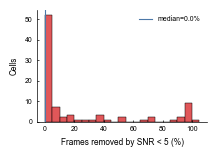

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SNR_manual_sidecar_diagnostics/Step4InterpolatedSNR_FrameRemovalDistribution_manual_good_frames.svg


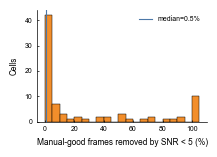

In [10]:
removed_all = snr_recompute_df["pct_removed_snr_threshold_all_frames"].to_numpy(dtype=float)
removed_all = removed_all[np.isfinite(removed_all)]
removed_good = snr_recompute_df["pct_removed_snr_threshold_manual_good"].to_numpy(dtype=float)
removed_good = removed_good[np.isfinite(removed_good)]

fig, ax = plt.subplots(figsize=(2.15, 1.55))
bins = np.linspace(0, max(5.0, np.nanpercentile(removed_all, 99) * 1.05), 22)
ax.hist(removed_all, bins=bins, color="#E15759", edgecolor="black", linewidth=0.35)
ax.axvline(np.nanmedian(removed_all), color="#4C78A8", linewidth=0.8, label=f"median={np.nanmedian(removed_all):.1f}%")
ax.set_xlabel(f"Frames removed by SNR < {SNR_THRESHOLD:g} (%)")
ax.set_ylabel("Cells")
ax.legend(frameon=False)
polish_axis(ax)
fig.tight_layout()
save_svg(fig, "Step4InterpolatedSNR_FrameRemovalDistribution_all_frames.svg")
plt.show()

fig, ax = plt.subplots(figsize=(2.15, 1.55))
bins = np.linspace(0, max(5.0, np.nanpercentile(removed_good, 99) * 1.05), 22)
ax.hist(removed_good, bins=bins, color="#F28E2B", edgecolor="black", linewidth=0.35)
ax.axvline(np.nanmedian(removed_good), color="#4C78A8", linewidth=0.8, label=f"median={np.nanmedian(removed_good):.1f}%")
ax.set_xlabel(f"Manual-good frames removed by SNR < {SNR_THRESHOLD:g} (%)")
ax.set_ylabel("Cells")
ax.legend(frameon=False)
polish_axis(ax)
fig.tight_layout()
save_svg(fig, "Step4InterpolatedSNR_FrameRemovalDistribution_manual_good_frames.svg")
plt.show()

## All-Cell Framewise `SNR_interpolated`

This heatmap shows the recomputed framewise `SNR_interpolated` for every manually processed cell. Rows are cells grouped by animal. Gray regions are frames that were already invalid under the manual/position/source-trace masks before applying the `SNR < 3.5` threshold.

/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_35419/2860411520.py:13: RuntimeWarning: All-NaN slice encountered
  out[:, bin_idx] = np.nanmedian(matrix[:, start:end], axis=1)
/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_35419/2860411520.py:13: RuntimeWarning: All-NaN slice encountered
  out[:, bin_idx] = np.nanmedian(matrix[:, start:end], axis=1)
/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_35419/2860411520.py:13: RuntimeWarning: All-NaN slice encountered
  out[:, bin_idx] = np.nanmedian(matrix[:, start:end], axis=1)
/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_35419/2860411520.py:13: RuntimeWarning: All-NaN slice encountered
  out[:, bin_idx] = np.nanmedian(matrix[:, start:end], axis=1)
/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_35419/2860411520.py:13: RuntimeWarning: All-NaN slice encountered
  out[:, bin_idx] = np.nanmedian(matrix[:, start:end], axis=1)
/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_3

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SNR_manual_sidecar_diagnostics/Step4InterpolatedSNR_AllCells_Heatmap.svg


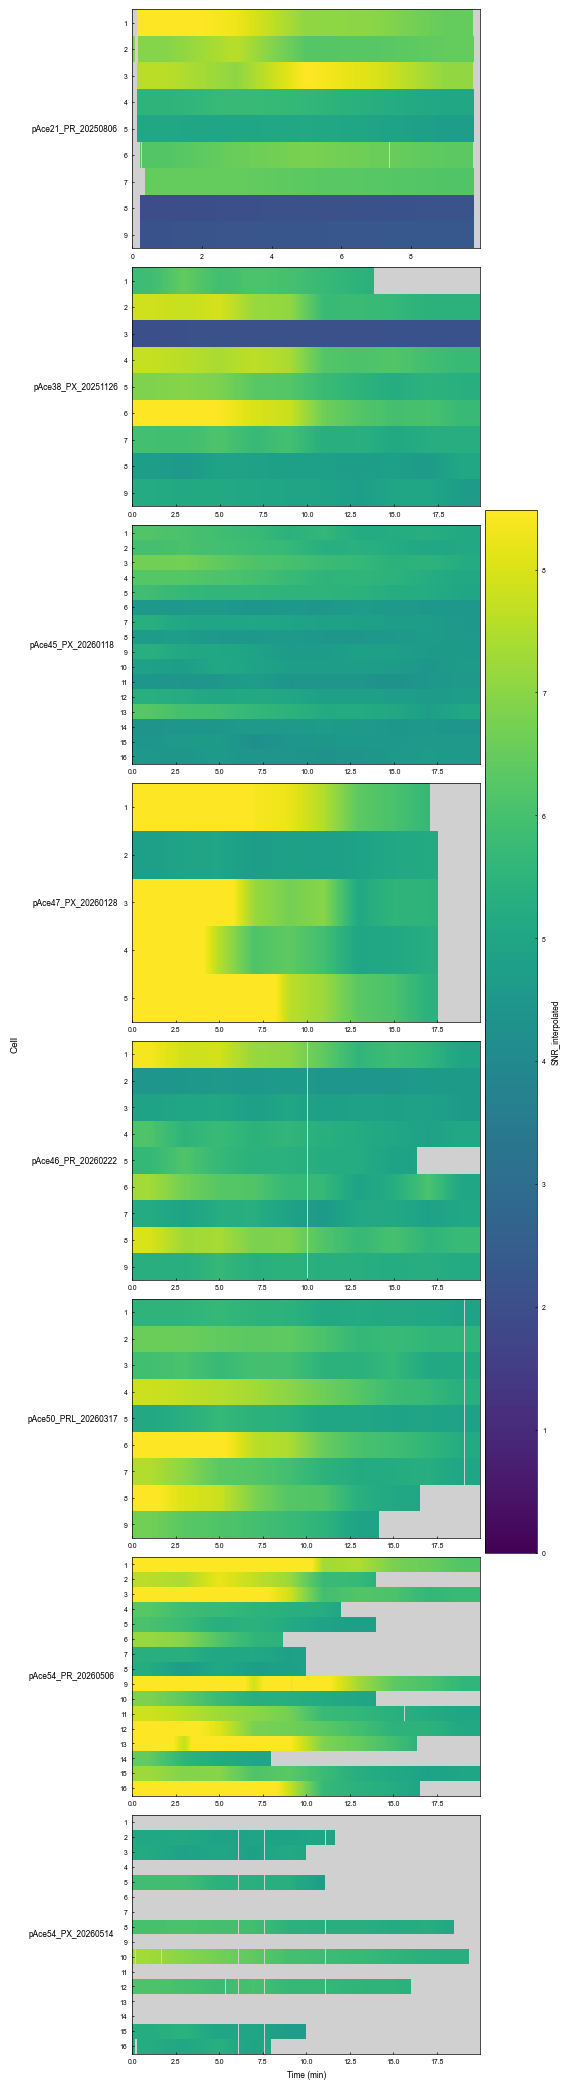

In [11]:
def downsample_nanmedian_2d(matrix: np.ndarray, max_bins: int = 2500) -> tuple[np.ndarray, np.ndarray]:
    matrix = np.asarray(matrix, dtype=float)
    n_rows, n_frames = matrix.shape
    if n_frames <= max_bins:
        return matrix, np.arange(n_frames + 1, dtype=int)
    edges = np.linspace(0, n_frames, int(max_bins) + 1).astype(int)
    edges = np.maximum.accumulate(edges)
    out = np.full((n_rows, int(max_bins)), np.nan, dtype=float)
    for bin_idx, (start, end) in enumerate(zip(edges[:-1], edges[1:])):
        if end <= start:
            continue
        with np.errstate(all="ignore"):
            out[:, bin_idx] = np.nanmedian(matrix[:, start:end], axis=1)
    return out, edges


snr_samples = []
for result in snr_recompute_by_cell.values():
    snr = np.asarray(result["SNR_interpolated"], dtype=float)
    finite = snr[np.isfinite(snr)]
    if finite.size:
        stride = max(1, finite.size // 20000)
        snr_samples.append(finite[::stride])
if snr_samples:
    snr_sample = np.concatenate(snr_samples)
    snr_color_max = max(float(SNR_THRESHOLD) + 0.5, float(np.nanpercentile(snr_sample, 95)))
else:
    snr_color_max = float(SNR_THRESHOLD) + 0.5

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("#D0D0D0")

fig_height = max(4.0, 0.22 * len(cell_df) + 1.2)
fig, axes = plt.subplots(len(ANIMAL_IDS), 1, figsize=(5.6, fig_height), constrained_layout=True)
axes = np.atleast_1d(axes)
last_im = None

for ax, animal_id in zip(axes, ANIMAL_IDS):
    payload = animal_payloads[animal_id]
    cell_ids = sorted(payload["cells"].keys())
    rows = []
    for cell_idx in cell_ids:
        result = snr_recompute_by_cell[(animal_id, int(cell_idx))]
        snr = np.asarray(result["SNR_interpolated"], dtype=float).copy()
        manual_bad = np.asarray(result["manual_bad_mask"], dtype=bool)
        if manual_bad.size == snr.size:
            snr[manual_bad] = np.nan
        rows.append(snr)
    matrix = np.vstack(rows) if rows else np.empty((0, payload["n_frames"]))
    matrix_ds, edges = downsample_nanmedian_2d(matrix, max_bins=2500)
    duration_min = float(payload["n_frames"]) / float(payload["frame_rate"]) / 60.0
    extent = [0.0, duration_min, len(cell_ids) + 0.5, 0.5]
    last_im = ax.imshow(
        matrix_ds,
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        vmin=0.0,
        vmax=snr_color_max,
        extent=extent,
        rasterized=True,
    )
    ax.set_ylabel(animal_id.replace("CKII_", ""), rotation=0, ha="right", va="center")
    ax.set_yticks(np.arange(1, len(cell_ids) + 1))
    ax.set_yticklabels([str(int(c) + 1) for c in cell_ids])
    ax.tick_params(width=0.5)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.set_xlim(0.0, duration_min)

axes[-1].set_xlabel("Time (min)")
fig.supylabel("Cell")
if last_im is not None:
    cbar = fig.colorbar(last_im, ax=axes, shrink=0.7, pad=0.015)
    cbar.set_label("SNR_interpolated")
    cbar.ax.tick_params(width=0.5)

save_svg(fig, "Step4InterpolatedSNR_AllCells_Heatmap.svg")
plt.show()

## Saved Versus Recomputed Check

This is a consistency check. Large deviations suggest that the notebook settings differ from the manual app settings used when the sidecar was saved.

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SNR_manual_sidecar_diagnostics/Saved_vs_Recomputed_OverallSNR.svg


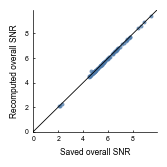

Saved summary table: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SNR_manual_sidecar_diagnostics/manual_snr_diagnostics_summary.csv


,animal_id,cell_idx,frame_rate,n_frames,duration_min,n_segments,n_segment_snr_finite,overall_snr_saved,snr_acceptable_until_s,manual_exclusion_frames,segment_baseline_count_min,snr_change_pct_until_manual_cutoff,overall_snr_recomputed,pct_removed_snr_threshold_all_frames,pct_removed_snr_threshold_manual_good,pct_manual_good_unknown_snr
0,CKII_pAce21_PR_20250806,0,500.0,299500,9.983333,5,5,7.498422,599.0,5623,52247.0,-25.341090,7.498783,0.00000,0.000000,0.0
1,CKII_pAce21_PR_20250806,1,500.0,299500,9.983333,5,5,6.706071,599.0,545,50678.0,-6.889788,6.706526,0.00000,0.000000,0.0
2,CKII_pAce21_PR_20250806,2,500.0,299500,9.983333,5,5,7.653611,599.0,3589,50676.0,-6.587602,7.653703,0.00000,0.000000,0.0
3,CKII_pAce21_PR_20250806,3,500.0,299500,9.983333,5,5,5.451571,599.0,3783,53654.0,-7.704735,5.451731,0.00000,0.000000,0.0
4,CKII_pAce21_PR_20250806,4,500.0,299500,9.983333,5,5,4.604557,599.0,4462,53766.0,4.318625,4.970226,36.77429,38.167434,0.0


In [12]:
fig, ax = plt.subplots(figsize=(1.65, 1.65))
x = snr_recompute_df["overall_snr_saved"].to_numpy(dtype=float)
y = snr_recompute_df["overall_snr_recomputed"].to_numpy(dtype=float)
finite = np.isfinite(x) & np.isfinite(y)
ax.scatter(x[finite], y[finite], s=8, color="#4C78A8", alpha=0.75, linewidths=0)
if np.any(finite):
    lim = [0, max(np.nanmax(x[finite]), np.nanmax(y[finite])) * 1.05]
    ax.plot(lim, lim, color="black", linewidth=0.6)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
ax.set_xlabel("Saved overall SNR")
ax.set_ylabel("Recomputed overall SNR")
polish_axis(ax)
fig.tight_layout()
save_svg(fig, "Saved_vs_Recomputed_OverallSNR.svg")
plt.show()

merged_summary = cell_df.merge(
    snr_change_df[["animal_id", "cell_idx", "snr_change_pct_until_manual_cutoff"]],
    on=["animal_id", "cell_idx"],
    how="left",
).merge(
    snr_recompute_df[[
        "animal_id",
        "cell_idx",
        "overall_snr_recomputed",
        "pct_removed_snr_threshold_all_frames",
        "pct_removed_snr_threshold_manual_good",
        "pct_manual_good_unknown_snr",
    ]],
    on=["animal_id", "cell_idx"],
    how="left",
)
summary_path = figure_save_folder / "manual_snr_diagnostics_summary.csv"
merged_summary.to_csv(summary_path, index=False)
print(f"Saved summary table: {summary_path}")
display(merged_summary.head())